# Jupyter Notebook
# Lec 16: Boostrap 

In this lab, we are going to follow along with the book to generate boostrap samples. 

While `sklearn` does have a method called [`Bootstrap`](https://ogrisel.github.io/scikit-learn.org/sklearn-tutorial/modules/generated/sklearn.cross_validation.Bootstrap.html), it doesn't quite do what we want in terms of the example from class.  So instead, we're going to use even simpler functions. 

##ANSWER## 

Instructor notes:
Add biased vs unbiased standard deviation estimate discussion: https://martin-ueding.de/posts/default-standard-deviation-estimators-in-python-numpy-and-r/

In [2]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## The Setup

We wish to invest a fixed sum of money in two financial assets that yield returns of $X$ and $Y$, respectively, where $X$ and $Y$ are random quantities. Return is defined as 

$$
R = \frac{V_f-V_i}{V_i}
$$

where $V_f$ is the final value of the investment, and $V_i$ is the initial value of the investment. In particular this means, return times the investment amount tells me how much money I make: 

$$
\text{Money I make} = V_f - V_i = R \cdot V_i
$$

We will invest a fraction $\alpha$ of our money in *Xylophone Services, Ltd*, and will invest the remaining $(1-\alpha)$ in *Yodeling Yaks, Inc*.

&#9989; **<font color=red>Q:</font>** Let's say I have $\$100$ and I invest $20\%$ of my money in the Xylophones, and the remaining $80\%$ in the Yaks.  If the Xyleophone company has a return of $X=1$, and the Yaks have a return of $Y = -0.50$, how much money do I make? Finish the code to answer this question below. 

In [3]:
X = 1 
Y = 0.5
alpha = .2 
myMoney  = 100

income = None #<--- Your code here

##ANSWER##

- I invest $\alpha \cdot 100$ in company X. So the money I make on X is $X \cdot (\alpha\cdot 100)$
- Likewise, I invest $(1-\alpha)\cdot 100$ and so the money I make on Y is $Y \cdot (1-\alpha) \cdot 100)$. 


In [4]:
##ANSWER##
X = 1 
Y = 0.5
alpha = .2 
myMoney = 100

income = 100* (X*alpha + (1-alpha)*Y)
income

60.00000000000001

&#9989; **<font color=red>Q:</font>** If instead I invest a dollar, what is my equation for income? 

##ANSWER##

$$
\texttt{income} = \alpha X + (1-\alpha)Y
$$

## Making Fake Data

Below is some code that generates the data sets as described in Ch 5.2. 


In [5]:
# Note that every time you rerun this function, you will get a new random sample.
def generatePortfolio(varX = 1, varY = 1.25,varXY = 0.5, seed = None):
    cov = np.array(((varX, varXY), (varXY, varY)))

    mean = (0,0)
    
    # This sets the seed if we don't want to generate a new data set each time
    np.random.seed(seed)
    
    # This generates our random data
    portfolio = np.random.multivariate_normal(mean, cov, (100))
    
    portfolio = pd.DataFrame(portfolio, columns = ['X', 'Y'])
    return portfolio

portfolio = generatePortfolio(seed = 42)
portfolio.head()


,X,Y
0,-0.306423,-0.567876
1,-1.447803,0.077964
2,0.328652,0.123879
3,-1.717033,-1.225487
4,0.036144,0.734641


Text(0, 0.5, 'Y')

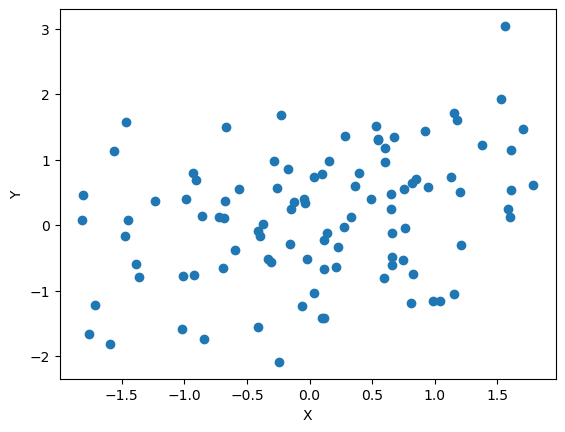

In [6]:
plt.scatter(portfolio.X, portfolio.Y)
plt.xlabel('X')
plt.ylabel('Y')

I want to see how much money I'd make in each case based on a fixed $\alpha$. For the sake of all this, I can assume that I'm just investing a dollar since my goal will be to just minimize the variance of the income. 

I can color the points by the amount of income I would get if that pair of $X$ and $Y$ values occurred. 

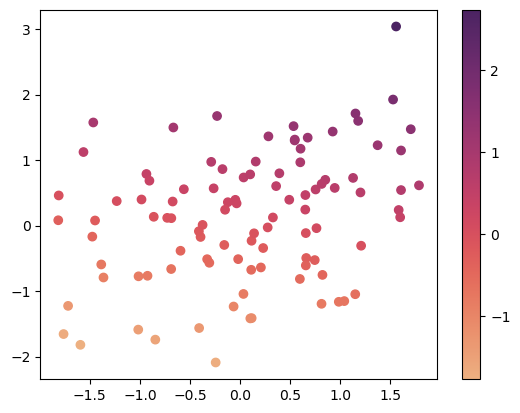

In [7]:
alpha = 0.2 #<----- Messing with this number, changes what percentage I invest
            #       in each company. 

income = portfolio.X*alpha + (1-alpha)*portfolio.Y #<--Make sure this equation makes 
                                                   # sense to you based on how you 
                                                   # figured out income above

plt.scatter(portfolio.X, portfolio.Y, c = income, cmap = 'flare')
plt.colorbar()

**<font color=red>Warning:</font>**  I'm following the book in that they call the second column $Y$, but we're not doing a variable prediction with this data set. We just happen to have  labeled the outputs of our two companies $X$ and $Y$. 

## Approximate $\hat \alpha$ with simulated data

We're assuming we're investing $\alpha$ percent of our money in stock $X$ and $(1-\alpha)$ percent of our money in stock $Y$. Our goal is to minimize the variance 

$$ \mathrm{Var}(\alpha X + (1-\alpha)Y)$$

In your homework, you will show that the variance is minimized when 

$$
\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}
$$

&#9989; **<font color=red>Do this:</font>** First, based on the parameters we used to simulate our data, determine the true value of $\alpha$ using the equation above. *(Hint: You know what the answer should be from the slides, so make sure you can calculate it based on our inputs)*

In [8]:
# Your code here

In [9]:
##ANSWER##
varX = 1
varY = 1.25
varXY = 0.5

num = varY - varXY
print(num)
denom = varX + varY  - 2 *varXY
print(denom)

print('True alpha:', num/denom)

0.75
1.25
True alpha: 0.6


Next, we will figure out how to approximate $\alpha$ using the computed covariance from our particular data set. We can find the values for variance and covariance for our simulated data in pandas' covariance matrix. 

In [10]:
portfolio.cov()

,X,Y
X,0.860247,0.295143
Y,0.295143,0.950825


&#9989; **<font color=red>Do this:</font>** Edit the function `alpha_hat` below which takes in a data frame and returns the predicted $\hat \alpha$ using the equation above. Use your function on the entire data set to get an estimate $\hat \alpha$.

In [11]:
def alpha_hat(df):
    # Your code here #
    pass 

    return 0 #<---- clearly this shouldn't always return 0
    

alpha_hat(portfolio)

0

In [12]:
##ANSWER## 

def alpha_hat(df):
    cov = np.array(df.cov())
    sigmaX = cov[0,0]
    sigmaY = cov[1,1]
    sigmaXY = cov[0,1]

    
    num = sigmaY - sigmaXY
    denom = sigmaX + sigmaY - 2 *sigmaXY
    
    
    return num/denom
    

alpha_hat(portfolio)

0.5370980450649352

Now, if your `alpha_hat` code is working, the following loop will generate 1000 data sets, calculate $\hat \alpha$ for each, and draw a histogram of the result. 

Mean: 0.6
StDev: 0.08


(array([  1.,  16.,  83., 173., 233., 262., 148.,  61.,  21.,   2.]),
 array([0.33004459, 0.38551148, 0.44097837, 0.49644526, 0.55191215,
        0.60737904, 0.66284593, 0.71831282, 0.77377972, 0.82924661,
        0.8847135 ]),
 <BarContainer object of 10 artists>)

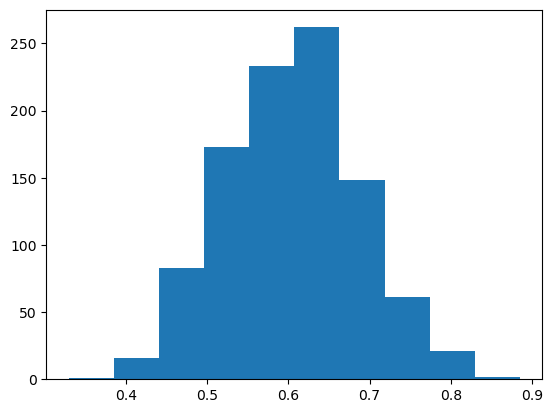

In [13]:
allAlphas = [] 
for i in range (1000):
    
    # Resimualte a new portfolio data set. Because I'm not passing 
    # in a seed, I get a new portfolio data set every time. 
    portfolio = generatePortfolio()
    
    # Compute the alpha_hat and append it to my list
    allAlphas.append(alpha_hat(portfolio))
    
print('Mean:', round(np.mean(allAlphas),2))
print('StDev:', round(np.std(allAlphas),2))

    
plt.hist(allAlphas)


![Stop Icon](https://upload.wikimedia.org/wikipedia/commons/thumb/1/1e/Vienna_Convention_road_sign_B2a.svg/180px-Vienna_Convention_road_sign_B2a.svg.png)

Great, you got to here! Hang out for a bit, there's more lecture before we go on to the next portion. 

## Resampling data 

Ok, so normally we don't have access to those original parameters to figure out what $\alpha$ actually should be, nor do we have the ability to simulate data for ourselves. So, the answer is the boostrap!

First, we get our data set. **<font color=red>Note</font>**: For the rest of this exercise, I pretend that I am not allowed to simulate anything. I was just handed this data set and it's all I get to work with. 

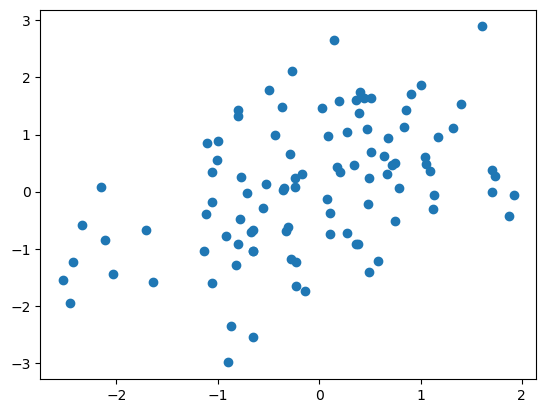

In [14]:
portfolio = generatePortfolio(seed = 0)
plt.scatter(portfolio.X, portfolio.Y)

The main thing we need to do is to sample our data set with replacement, which we can do with the `sample` function built into the data frame. In this function, `frac=1` means that we use 100% of our data (so we end up with $n$ samples from our original $n$ data points), and `replace=True` means we get to pick points with replacement 

In [15]:
samp_port = portfolio.sample(frac=1,replace=True)

print('Notice that the `samp_port` dataframe has 100 rows.')
print('Length of samp_port:', len(samp_port.index))

print('\nbut if we get rid of duplicates we have less \nthan 100 data points represented.')
print('Length of samp_port without duplicates:', len(set(samp_port.index)))
samp_port.head()

Notice that the `samp_port` dataframe has 100 rows.
Length of samp_port: 100

but if we get rid of duplicates we have less 
than 100 data points represented.
Length of samp_port without duplicates: 65


,X,Y
35,-0.654051,-0.674052
58,-0.651234,-1.030747
49,-0.347422,0.065036
73,0.032066,1.458233
44,0.195051,1.587604


&#9989; **<font color=red>Do this:</font>** Repeat the following procedure 1000 times:
- Generate a new sample of your `portfolio` data set (Note: DO NOT resimulate your portfolio data set)
- Use your `alpha_hat` function from above to compute $\hat \alpha$ and keep it in your list

Then, draw a histogram of the results. 

[]


(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

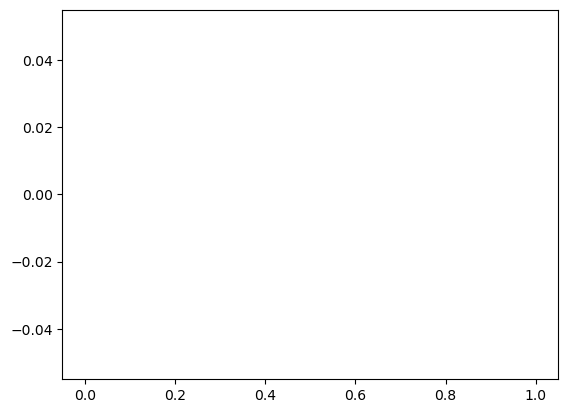

In [16]:
alphahats = []
B = 1000 #<---- maybe set this to 10 or so while you're debugging

for i in range(B):
    
    # Put your code in here
    pass

# a printout for debugging
print(alphahats[:10])

plt.hist(alphahats)

In [17]:
##ANSWER## 

alphahats = []
B = 1000

for i in range(B):
    samp_port = portfolio.sample(frac=1,replace=True)
    a = alpha_hat(samp_port)
    alphahats.append(a)

# alphahats[:10]

(array([  3.,  17.,  51., 163., 235., 233., 178.,  81.,  31.,   8.]),
 array([0.34923594, 0.40239045, 0.45554495, 0.50869946, 0.56185397,
        0.61500848, 0.66816299, 0.7213175 , 0.77447201, 0.82762652,
        0.88078103]),
 <BarContainer object of 10 artists>)

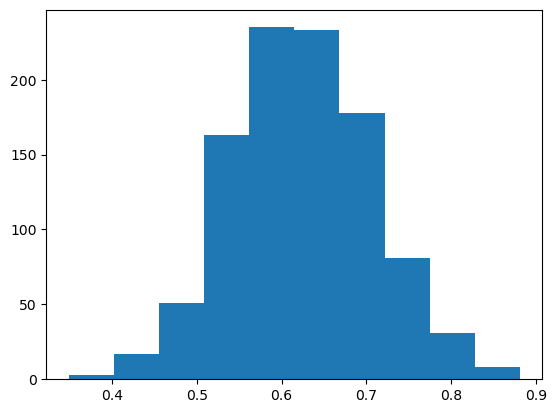

In [18]:
##ANSWER##

plt.hist(alphahats)

The last thing to do is determine the error estimate. Eqn 5.8 in the book says that we can estimate the error using 

$$
SE_B(\hat \alpha) = \sqrt{ \frac{1}{B-1}
	\sum_{r=1}^B \left(
	\hat \alpha^{*r} - \frac{1}{B}\sum_{r'=1}^B \hat \alpha^{*r'}
	\right)^2
	}
    $$
	
where $\hat \alpha^{*i}$ is the $i$th prediction (AKA the $i$th entry in your `alphahats` list up there). 

&#9989; **<font color=red>Do this:</font>** Use your `alphahats` list  to determine the standard error of $\hat \alpha$. 

In [19]:
# Your code here

In [20]:
##ANSWER##

alpha_avg = np.average(alphahats)
np.sqrt( np.sum ( (alphahats - alpha_avg)**2 ) / (B-1))



0.08300976798142048

In [21]:
##ANSWER##
print(np.sqrt(np.var(alphahats)))
# Note: note quite the same!
print(np.std(alphahats))

# This fixes the problem because of how numpy calculates standard deviation
print(np.std(alphahats,ddof=1))

0.08296825271601742
0.08296825271601742
0.08300976798142048


##ANSWER## 

*Idea for later but i'm just outta juice*

The bootstrap for linear regression:

The book has a version of this where we do bootstrap estimation of linear regression variables, and compares them to the standard error automatically computed by the stats package (or maybe we can hard code the quantity?



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [24]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)


Myfilename CMSE381-Lec16-Bootstrap-INSTRUCTOR.ipynb


CMSE381-Lec16_Bootstrap.ipynb


Validating Notebook ./CMSE381-Lec16_Bootstrap.ipynb
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: Image LINK not found - http://creativecommons.org/licenses/by-nc/4.0/
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..
   ERROR: No Alt text in image - data:image/png;base64,iVBORw0KGgoAAAANSUhE..


6